## Teoría de Juegos Evolutivos en Poblaciones de Guppies

#### Librerías

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

#### Elementos Gráficos

In [2]:
colors = plt.cm.viridis([0.05, 0.25, 0.45, 0.65, 0.85])

### Parámetros Biológicos

In [3]:
#parámetros utilizados 
#Reproducción y Muerte
s_a = 0.8; s_b = 0.03; d_a = 0.107; d_b = 0.023 # Valores NO arbitrarios sacados de [4] y [7]

---

### Proceso de moran clásico 

Definimos **N** como la población de Guppies, **p** como la proporción inicial de individuos de tipo A, siendo los de A los que tienen una coloración más brillante y B como los que tienen una coloración más opaca. Tomamos una lista dada la proporción inicial de "A" y "B". Luego de forma totalmente aleatoria los reproducimos y dejamos morir en la misma proporción. 

In [4]:
def moranProcess(N, p, T):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N) 
    history = [p]
    for _ in range(T):
        to_die = random.randrange(len(population)) 
        reproducer = random.randrange(len(population))
        population[to_die] = population[reproducer]
        history.append((population.count('A') / len(population)))
    return history, (population.count('A') / len(population))

moranProcess(N=1000, p=0.5, T= 1000)[1]

0.507

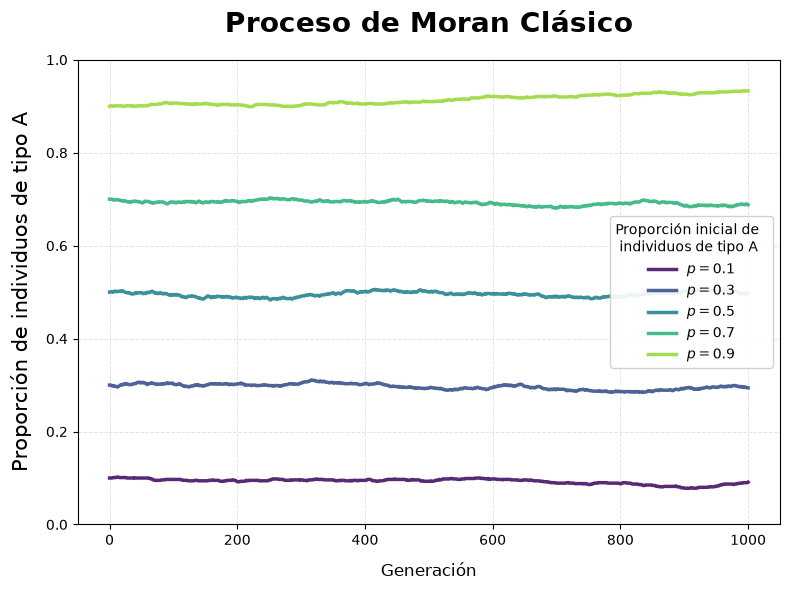

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

p = [0.1, 0.3, 0.5, 0.7, 0.9]
for prop, color in zip(p, colors):
    generaciones = moranProcess(N=1000, p=prop, T=1000)[0]
    ax.plot( generaciones, label=fr'$p = {prop}$', color=color, linewidth=2.5, alpha=0.9)

ax.set_xlabel('Generación', fontsize=12, labelpad=10)
ax.set_ylabel('Proporción de individuos de tipo A', fontsize=15, labelpad=10)
ax.set_title( 'Proceso de Moran Clásico', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.grid( True, linestyle='--', linewidth=0.7, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.legend( 
    title='Proporción inicial de  \n individuos de tipo A',
    fontsize=10,
    title_fontsize=10,
    loc='best',
    frameon=True,
    fancybox=True,
    framealpha=0.9
)


plt.tight_layout()
plt.savefig('../Gráficas/Proceso_Moran_Clasico.png')
plt.show()

Acá no tenemos en cuenta nada más que la estocacidad del proceso, por lo que la proporción final de individuos de tipo A puede variar en cada ejecución además vemos que en promedio queda en la misma proporición inicial acorde a lo visto anteriormente sin llegar a estados absorbentes siendo muy alejado al juego de los Guppies.

---

## Proceso de Moran Fitness Fijo

Acá vamos a simular un proceso de Moran utilizando pesos estadísticos dados por el fitness de la población de A dónde decimos que se va reproducir **si el fitness A es mayor al fitness total** y va a morir de forma aleatoria cualquier individuo sin importar el fitness ni la depredación.


In [6]:
def moranProcessFitness(N, p, T):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    fit_a = 1 + s_a-d_a
    fit_b = 1 + s_b-d_b
    population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N) 
    history = []
    for _ in range(T):
        to_die = random.choice(population) 
        if random.random() < fit_a / (fit_a + fit_b):
            reproducer = 'A'
        else:
            reproducer = 'B'
        population[population.index(to_die)] = reproducer 
        history.append(population.count('A') / len(population))
    return round(population.count('A') / len(population), 1), history

moranProcessFitness(N=1000, p=0.5, T= 1000)[0]

0.6

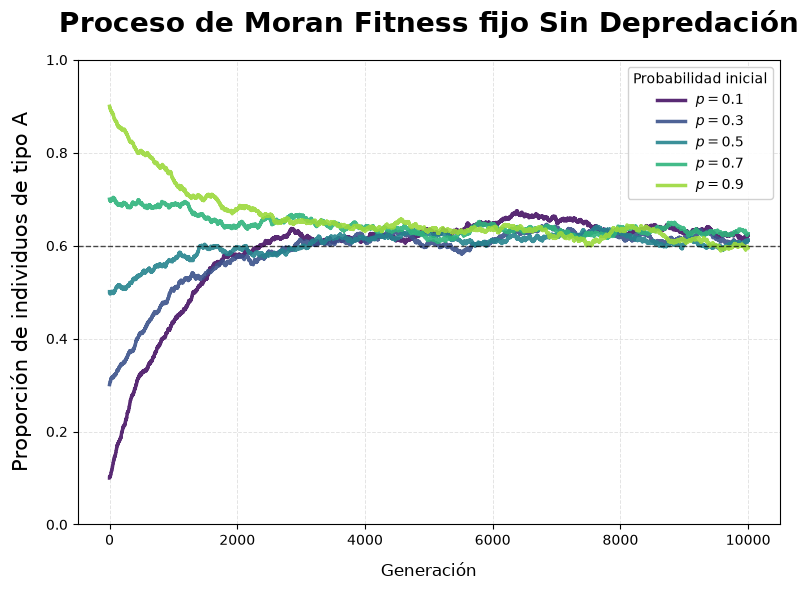

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

p = [0.1, 0.3, 0.5, 0.7, 0.9]
for prop, color in zip(p, colors):
    generaciones = moranProcessFitness(N=1000, p=prop, T=10000)[1]
    ax.plot( generaciones, label=fr'$p = {prop}$', color=color, linewidth=2.5, alpha=0.9)

ax.set_xlabel('Generación', fontsize=12, labelpad=10)
ax.set_ylabel('Proporción de individuos de tipo A', fontsize=15, labelpad=10)
ax.set_title( 'Proceso de Moran Fitness fijo Sin Depredación', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.axhline(0.6, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.grid( True, linestyle='--', linewidth=0.7, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.legend( 
    title='Probabilidad inicial',
    fontsize=10,
    title_fontsize=10,
    loc='best',
    frameon=True,
    fancybox=True,
    framealpha=0.9
)


plt.tight_layout()
plt.savefig('../Gráficas/Proceso_Moran_Fitness_Fijo_Sin_Depredacion.png')
plt.show()

Acá vemos que hay en promedio serán mayor porción de A's que de B's oscilando cerca de 0.6 sin importar que proporción inicial sea de cada individuo. Tiene sentido pensar que a mayor belleza por parte de los peces macho guppies más serán elegidos por los peces pero es de gran importancia cómo se elige quién muere porque no se logran fijar el alelo A.

---
### Proceso de Moran con Fitness y Tasa de Depredación

Además podríamos definir un fitness fijo para los individuos tipos A y B además de una tasa de depredación fija para cada uno acorde a que tan bellos o no sean.

In [8]:
def moranProcessFitnessDepredacion(N, p, T):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    fit_a = 1+s_a-d_a
    fit_b = 1 + s_b-d_b
    population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N) 
    history = []
    for _ in range(T):
        to_die = random.choices(population, weights=[1 + d_a if x == 'A' else 1 + d_b for x in population])[0]
        if random.random() < fit_a / (fit_a + fit_b):
            reproducer = 'A'
        else:
            reproducer = 'B'
        population[population.index(to_die)] = reproducer 
        history.append(population.count('A') / len(population))
    return round(population.count('A') / len(population), 1), history

moranProcessFitnessDepredacion(N=1000, p=0.5, T= 1000)[0]

0.6

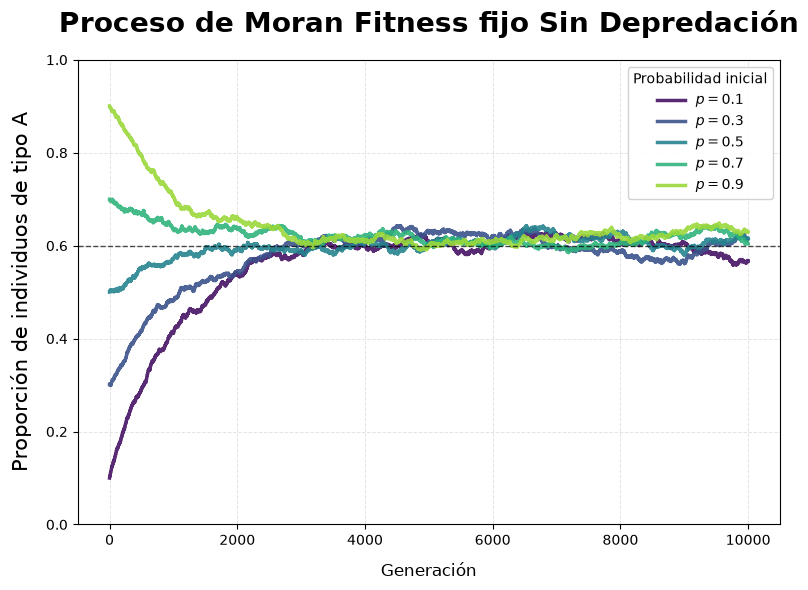

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

p = [0.1, 0.3, 0.5, 0.7, 0.9]
for prop, color in zip(p, colors):
    generaciones = moranProcessFitnessDepredacion(N=1000, p=prop, T=10000)[1]
    ax.plot( generaciones, label=fr'$p = {prop}$', color=color, linewidth=2.5, alpha=0.9)

ax.set_xlabel('Generación', fontsize=12, labelpad=10)
ax.set_ylabel('Proporción de individuos de tipo A', fontsize=15, labelpad=10)
ax.set_title( 'Proceso de Moran Fitness fijo Sin Depredación', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.axhline(0.6, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.grid( True, linestyle='--', linewidth=0.7, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.legend( 
    title='Probabilidad inicial',
    fontsize=10,
    title_fontsize=10,
    loc='best',
    frameon=True,
    fancybox=True,
    framealpha=0.9
)


plt.tight_layout()
plt.savefig('../Gráficas/Proceso_Moran_Fitness_Fijo_Con_Depredacion.png')
plt.show()

Acá vemos que hay en promedio serán mayor porción de A's que de B's oscilando abajo de 0.6 y es más estrecha a comparación de la situación anterior. Dónde se ve con claridad una desventaja  de depredación para aquellos peces que son más atractivos para los depredadores.

---

### Proceso de Moran con Fitness y Tasa de Depredación Dependiendo de la Frecuencia.

Ahora el fitness dependerá plenamente de la frecuencia del gen en la población, es decir, el fitness depende de la frecuencia y la facilidad en la que se los comen también. 
Ya se encuentran en un estado más vulnerable si hay demasiados de ellos porque en cardumen llaman mucho la atención de los depredadores además si hay poca frecuencia de estos habrá mayor facilidad de reproducción porque llaman la atención de las hembras. 

In [ ]:
def moranProcessFreqFitness(N, p, T):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N) 
    p0 = p 
    history = [p0]
    for _ in range(T):
        fit_a_freq = (1 + s_a*(1-p0) - d_a(1-p0))
        fit_b_freq = (1 + s_b*(p0) - d_b*(p0)) 
        die_a_freq = d_a*p0 
        die_b_freq = d_b*(1-p0)
        to_die = random.choices(population, weights=[die_a_freq if x == 'A' else die_b_freq for x in population])[0]
        reproducer = random.choices(population, weights=[fit_a_freq if x == 'A' else fit_b_freq for x in population])[0]
        population[population.index(to_die)] = reproducer 
        p0 = population.count('A') / len(population)
        history.append(p0)
    return round(p0,3), history

def moranProcessFreqFitness(N, p, T):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N)
    p0 = p
    history = [p0]

    for _ in range(T):
        # fitness dependiente de la frecuencia
        fit_a_freq = 1 + s_a * (1 - p0) - d_a * (1 - p0)
        fit_b_freq = 1 + s_b * p0 - d_b * p0

        # probabilidad de morir por tipo
        die_a_freq = d_a * p0
        die_b_freq = d_b * (1 - p0)

        to_die = random.choices(
            population,
            weights=[die_a_freq if x == 'A' else die_b_freq for x in population]
        )[0]

        reproducer = random.choices(
            population,
            weights=[fit_a_freq if x == 'A' else fit_b_freq for x in population]
        )[0]

        population[population.index(to_die)] = reproducer
        p0 = population.count('A') / len(population)
        history.append(p0)

    return round(p0, 3), history

moranProcessFreqFitness(N=1000, p=0.5, T=1000)[0]

TypeError: 'float' object is not callable

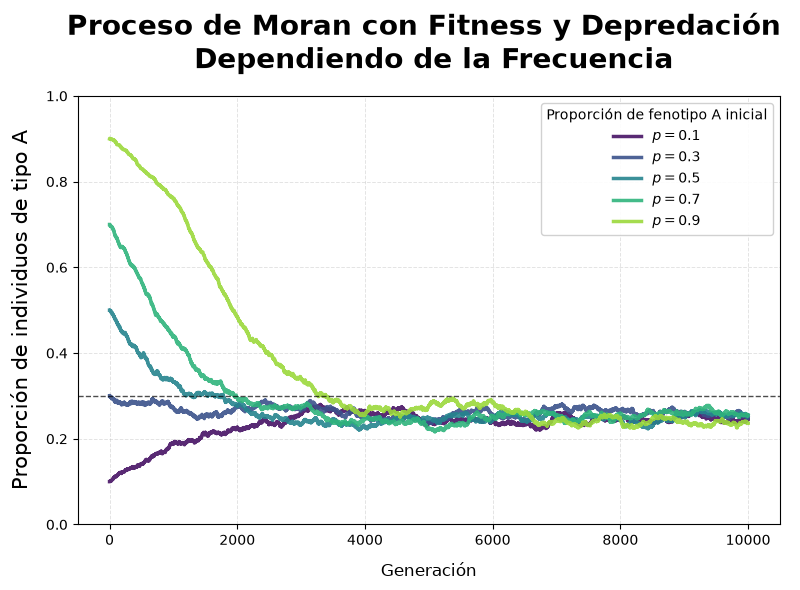

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for prop, color in zip(p, colors):
    generaciones = moranProcessFreqFitness(N=1000, p=prop, T=10000)[1]
    ax.plot( generaciones, label=fr'$p = {prop}$', color=color, linewidth=2.5, alpha=0.9)

ax.set_xlabel('Generación', fontsize=12, labelpad=10)
ax.set_ylabel('Proporción de individuos de tipo A', fontsize=15, labelpad=10)
ax.set_title( 'Proceso de Moran con Fitness y Depredación \n Dependiendo de la Frecuencia', fontsize=20, fontweight='bold', pad=20)
ax.set_ylim(0, 1)
ax.axhline(0.3, color='black', linestyle='--', linewidth=1, alpha=0.7)
ax.grid( True, linestyle='--', linewidth=0.7, alpha=0.35)
ax.tick_params(axis='both', labelsize=10)
ax.legend( 
    title='Proporción de fenotipo A inicial',
    fontsize=10,
    title_fontsize=10,
    loc='best',
    frameon=True,
    fancybox=True,
    framealpha=0.9
)


plt.tight_layout()
plt.savefig('../Gráficas/Proceso_Moran_Fitness_y_Depredacion_freq.png')
plt.show()

Teniendo en cuenta que tendremos depredación y apareamiento acorde a un fitness móvil que depende de la frecuencia. Vemos que habrá mayor población de A's que de B's fijándose en un poco menos de 0.3 luego de unas 2000-3000 generaciones sin importar con qué población inicia. 

--- 

Ahora voy a introducir un fetonotipo que me pueda llevar a cabo una categoría de un pez "activo" y uno que sea menos activo. Esto ha sido una constante en algunos papers que hablan sobre una relación de vigurosidad y facilidad de salir intactos contra depredadores. Por otro lado, hay algunos que relacionan las manchas naranajas las cuáles podrían mostrar vigurosidad en algunos peces. Podríamos hacer de forma estocástica la selección de los peces más vigurosos dándole más peso a los que tienen el fenotipo A. 


In [ ]:
v = 0.6 # La prob de que un individuo A sea vigoroso hay que revisarlo
p_v = 0 # Que tan prob es que el individuo se escape de la depredación, hay que revisarlo
def poblacionvigorosa(p, v, N):
    """
    Genera una población de tamaño N con una proporción inicial p de individuos de tipo A y (1-p) de tipo B.
    Cada individuo tiene una probabilidad v de ser vigoroso.
    Devuelve la población generada.
    """
    population = ['A'] * int(p * N) + ['B'] * int((1 - p) * N) 
    for i in range(len(population)):
        if population[i] == 'A':
            if random.random() < v:
                population[i] = 'AC'
            else: 
                population[i] = 'AD'

        else:
            if random.random() < (1-v):
                population[i] = 'BC'
            else: 
                population[i] = 'BD'
    return population

p= 0.5
poblacion= poblacionvigorosa(p, v, N=1000)
print(poblacion.count('AC')/len(poblacion), poblacion.count('AD')/len(poblacion), poblacion.count('BC')/len(poblacion), poblacion.count('BD')/len(poblacion))

In [ ]:
def moranProcessFreqFitnessVigor(N, p, T,s_a, s_b, d_a , d_b , v, p_v):
    """
    Simula un proceso de Moran para una población de tamaño N, con una proporción inicial p de individuos de tipo A y T generaciones.
    Devuelve la proporción final de individuos de tipo A después de T generaciones.
    """
    population = poblacionvigorosa(p, v, N)
    p0 = p 
    history = [p0]
    for _ in range(T):
        fit_a_freq = (1 + s_a*(1-p0) - d_a*p0)
        fit_b_freq = (1 + s_b*(p0) - d_b*(1-p0)) 
        die_a_freq = d_a*p0 - p_v
        die_b_freq = d_b*(1-p0)
        die_c_freq = p_v
        die_d_freq = 0
        to_die = random.choices(population, weights=[die_a_freq if x in ['AC', 'AD'] else die_b_freq for x in population])[0]
        reproducer = random.choices(population, weights=[fit_a_freq if x in ['AC', 'AD'] else fit_b_freq for x in population])[0]
        population[population.index(to_die)] = reproducer 
        p0 = sum(1 for x in population if x in ['AC', 'AD']) / len(population)
        history.append(p0)
    return round(p0,3), history

print("hola")


---

### Matriz de Markov
Ahora, para hacerlo más chévere, voy a construir una matriz de probabilidades/Markov, que tendrá un tamaño de (N+1) × (N+1), donde N es el tamaño de la población. Cada elemento de esta matriz representará la probabilidad de transición entre estados, es decir, la probabilidad de que el número de individuos de tipo A pase de un valor i a un valor i-1 (disminuya en uno), i+1 (aumente en uno) o se mantenga en i, para todos los estados intermedios donde 0 < i < N. Los estados extremos i=0 e i=N son considerados absorbentes, lo que significa que una vez que la población alcanza estos estados (todos individuos de tipo B o todos de tipo A, respectivamente), permanece en ellos con probabilidad 1.

In [ ]:
def matrix(N,  d_a, d_b, s_a, s_b):
    """
    Construye la matriz de transición para un proceso de Moran con selección y deriva.
    N: tamaño de la población
    s_a: ventaja selectiva del tipo A
    s_b: ventaja selectiva del tipo B
    d_a: deriva del tipo A
    d_b: deriva del tipo B
    """
    T_matrix = np.zeros((N+1, N+1))
    T_matrix[0, 0] = 1; T_matrix[N, N] = 1     # Estados absorbentes
    
    for i in range(1, N):
        freq_a = i / N
        freq_b = 1 - freq_a
        
        #Facilidad de reproducción y muerte acorde a la frecuencia actual
        fit_a = 1 + s_a * freq_a - d_a * freq_a
        fit_b = 1 + s_b * freq_b - d_b * freq_b
        total_fit = fit_a + fit_b
        die_a = d_a * freq_a
        die_b = d_b * freq_b

        T_matrix[i, i-1] = round(die_a * (fit_b / total_fit), 5)
        T_matrix[i, i+1] = round(die_b * (fit_a / total_fit), 5)
        T_matrix[i, i] = round(1 - T_matrix[i, i-1] - T_matrix[i, i+1], 5)
    
    return T_matrix

T = matrix(N= 10, d_a=0.78, d_b=0.22, s_a=0.8, s_b=0.03)